# convolve-rs vs RACS-tools benchmark

Compares **convolvers** (this crate's CLI) against **beamcon_2D** (RACS-tools) on
synthetic FITS images: wall time, CPU usage (mean cores busy) and peak RSS, plus a
correctness check that the smoothed outputs agree.

## Prerequisites
- `convolvers` — `cargo install --path .`, or this notebook auto-detects a local
  `../target/release/convolvers` dev build.
- `beamcon_2D` — from [RACS-tools](https://github.com/alecthomson/RACS-tools),
  e.g. `pip install racs-tools` (must be importable on `PATH`).
- Benchmark Python deps: `uv sync --extra benchmark` (matplotlib, astropy, pandas).

## Run
`Cell → Run All`, or headless:
```
uv run --extra benchmark jupyter nbconvert --execute --to notebook --inplace scripts/benchmark.ipynb
```
Outputs (data, smoothed FITS, plots) are written under `bench_out/` and gitignored.

## Configuration
Edit the two binary paths if they are not on your `PATH`.

In [15]:
import os
import platform
import re
import shutil
import subprocess
import time
from pathlib import Path

import make_dummy_fits as mdf  # sibling script, reused for data generation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits

# --- binaries under test -----------------------------------------------------
# Override either with an env var if it is not on your PATH, e.g.
#   CONVOLVERS_BIN=/path/to/convolvers BEAMCON_BIN=/path/to/beamcon_2D jupyter ...
_dev = Path("../target/release/convolvers")  # prefer a local dev build if present
CONVOLVERS = (
    os.environ.get("CONVOLVERS_BIN")
    or (str(_dev.resolve()) if _dev.exists() else None)
    or shutil.which("convolvers")
    or "convolvers"
)
BEAMCON = os.environ.get("BEAMCON_BIN") or shutil.which("beamcon_2D") or "beamcon_2D"
print("convolvers:", CONVOLVERS)
print("beamcon_2D:", BEAMCON)

# --- benchmark settings -------------------------------------------------------
# Fixed circular target beam, larger than every generated input beam (<=15").
TARGET = ["--bmaj", "20", "--bmin", "20", "--bpa", "0"]
WORK = Path("bench_out")
IS_MAC = platform.system() == "Darwin"

# Display label -> beamcon executor (None means the convolvers binary).
# beamcon's `thread` executor is GIL-bound; `process` uses a worker pool.
RUNNERS = {
    "convolvers": None,
    "beamcon-thread": "thread",
    "beamcon-process": "process",
}

convolvers: /Users/alec.thomson/SKAO Dropbox/Alec Thomson/repos/convolve-rs/target/release/convolvers
beamcon_2D: /Users/alec.thomson/SKAO Dropbox/Alec Thomson/repos/convolve-rs/.venv/bin/beamcon_2D


## Helpers

In [ ]:
def _tree_rss_kb(root: int) -> int:
    """Summed RSS (KB) of `root` plus all descendant processes.

    /usr/bin/time's `maximum resident set size` is per-process, so for a tool
    that forks workers (beamcon's process executor) it captures only the parent
    and under-counts true memory several-fold. Summing the tree fixes that. RSS
    sums double-count shared/COW pages, so this is an upper bound — but far closer
    than parent-only, and exact for single-process tools like convolvers.
    """
    out = subprocess.run(
        ["ps", "-axo", "pid,ppid,rss"], check=False, capture_output=True, text=True
    ).stdout
    rss, ppid = {}, {}
    for line in out.splitlines()[1:]:
        parts = line.split()
        if len(parts) < 3:
            continue
        pid, pp, r = int(parts[0]), int(parts[1]), int(parts[2])
        rss[pid], ppid[pid] = r, pp
    desc, changed = {root}, True
    while changed:
        changed = False
        for pid, pp in ppid.items():
            if pp in desc and pid not in desc:
                desc.add(pid)
                changed = True
    return sum(rss.get(p, 0) for p in desc)


def run_timed(cmd: list[str], env_extra: dict | None = None) -> dict:
    """Run cmd under /usr/bin/time -l; return wall/cpu_pct/cores/rss_mb.

    cores = (user + sys CPU seconds) / wall — the mean number of CPUs kept busy.
    """
    env = {**os.environ, **(env_extra or {})}
    proc = subprocess.Popen(
        ["/usr/bin/time", "-l", *cmd],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.PIPE,
        text=True,
        env=env,
    )
    t0 = time.perf_counter()
    peak_kb = 0
    while proc.poll() is None:
        peak_kb = max(peak_kb, _tree_rss_kb(proc.pid))
        time.sleep(0.03)
    wall = time.perf_counter() - t0
    err = proc.stderr.read()
    if proc.returncode != 0:
        raise RuntimeError(err)

    user = float(re.search(r"([\d.]+)\s+user", err).group(1))
    sys_ = float(re.search(r"([\d.]+)\s+sys", err).group(1))
    # Peak RSS is the sampled process-tree total (see _tree_rss_kb); time's own
    # maxrss is parent-only and under-counts fork-based worker pools several-fold.
    return {
        "wall": wall,
        "cpu_pct": 100 * (user + sys_) / wall,
        "cores": (user + sys_) / wall,
        "rss_mb": peak_kb / 1024,
    }


def gen_data(data: Path, n: int, size: int, sources: int = 500, seed: int = 1234):
    """Write n dummy FITS images via make_dummy_fits helpers; return paths."""
    data.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)
    pix_deg = 2.5 / 3600.0
    for i in range(n):
        bmaj = rng.uniform(10.0, 15.0) / 3600.0
        bmin = bmaj * rng.uniform(0.5, 1.0)
        bpa = rng.uniform(0.0, 180.0)
        hdr = mdf.make_header(size, pix_deg, bmaj, bmin, bpa)
        arr = mdf.make_data(size, sources, rng)
        fits.writeto(data / f"dummy_{i:04d}.fits", arr, hdr, overwrite=True)
    return sorted(str(p) for p in data.glob("*.fits"))


def build_cmd(label: str, infiles: list[str], outdir: Path) -> list[str]:
    outdir.mkdir(parents=True, exist_ok=True)  # binary fast-fails if -o is missing
    executor = RUNNERS[label]
    if executor is None:
        return [CONVOLVERS, "2d", "-o", str(outdir), *TARGET, *infiles]
    return [BEAMCON, "-o", str(outdir), "--executor", executor, *TARGET, *infiles]


def max_abs_diff(dir_a: Path, dir_b: Path) -> float:
    """Largest |Δ| over matched smoothed images between two output dirs."""
    worst = 0.0
    for fa in sorted(dir_a.glob("*.sm.fits")):
        fb = dir_b / fa.name
        if not fb.exists():
            continue
        a = fits.getdata(fa).squeeze().astype(np.float64)
        b = fits.getdata(fb).squeeze().astype(np.float64)
        worst = max(worst, float(np.nanmax(np.abs(a - b))))
    return worst


def bench_runner(label: str, infiles: list[str], root: Path, reps: int = 3) -> dict:
    """Median-by-wall metrics over `reps`, each into its own fresh output dir.

    Inputs are always read from a separate `data/` dir and outputs written to a
    per-run dir, so timings are never polluted by re-reading prior `*.sm.fits`.
    """
    runs = [
        run_timed(build_cmd(label, infiles, root / f"{label}_r{r}"))
        for r in range(reps)
    ]
    runs.sort(key=lambda d: d["wall"])
    return runs[len(runs) // 2]


def run_case(
    tag: str, n: int, size: int, sources: int = 500, reps: int = 3
) -> pd.DataFrame:
    """Run every runner for one (n, size); return one median row per runner."""
    root = WORK / tag
    infiles = gen_data(root / "data", n, size, sources)
    rows = []
    for label in RUNNERS:
        m = bench_runner(label, infiles, root, reps)
        rows.append(
            {
                "runner": label,
                "n": n,
                "size": size,
                "mpix_total": n * size * size / 1e6,
                **m,
            }
        )
    return pd.DataFrame(rows)

## Single run

One batch of images through all three runners (median of 3). `max_abs_vs_rs` is
the largest pixel difference of each beamcon output against the convolvers
reference — it should sit at float32 round-off.

In [ ]:
single = run_case("single", n=10, size=1024)
root = WORK / "single"
acc = {
    label: max_abs_diff(root / "convolvers_r0", root / f"{label}_r0")
    for label, executor in RUNNERS.items()
    if executor is not None
}
print("max |Δ| vs convolvers:", {k: f"{v:.2e}" for k, v in acc.items()})
single.set_index("runner")[["wall", "cpu_pct", "cores", "rss_mb"]].round(3)

## Scaling sweeps

Vary the image **count** (fixed size) and image **size** (fixed count). Single run
per point — these show trends, not precise numbers.

In [ ]:
def sweep(axis: str, values: list[int], n=8, size=1024, sources=500) -> pd.DataFrame:
    frames = []
    for v in values:
        nn, sz = (v, size) if axis == "n" else (n, v)
        case = run_case(f"{axis}{v}", nn, sz, sources, reps=1)
        case["axis_value"] = v
        frames.append(case)
    return pd.concat(frames, ignore_index=True)


sweep_n = sweep("n", [1, 2, 5, 10, 20], size=1024)
sweep_sz = sweep("size", [512, 1024, 2048, 4096], n=8)
sweep_n.pivot_table(index="axis_value", columns="runner", values="wall").round(2)

## Summary plots

wrote bench_out/scaling_count.png


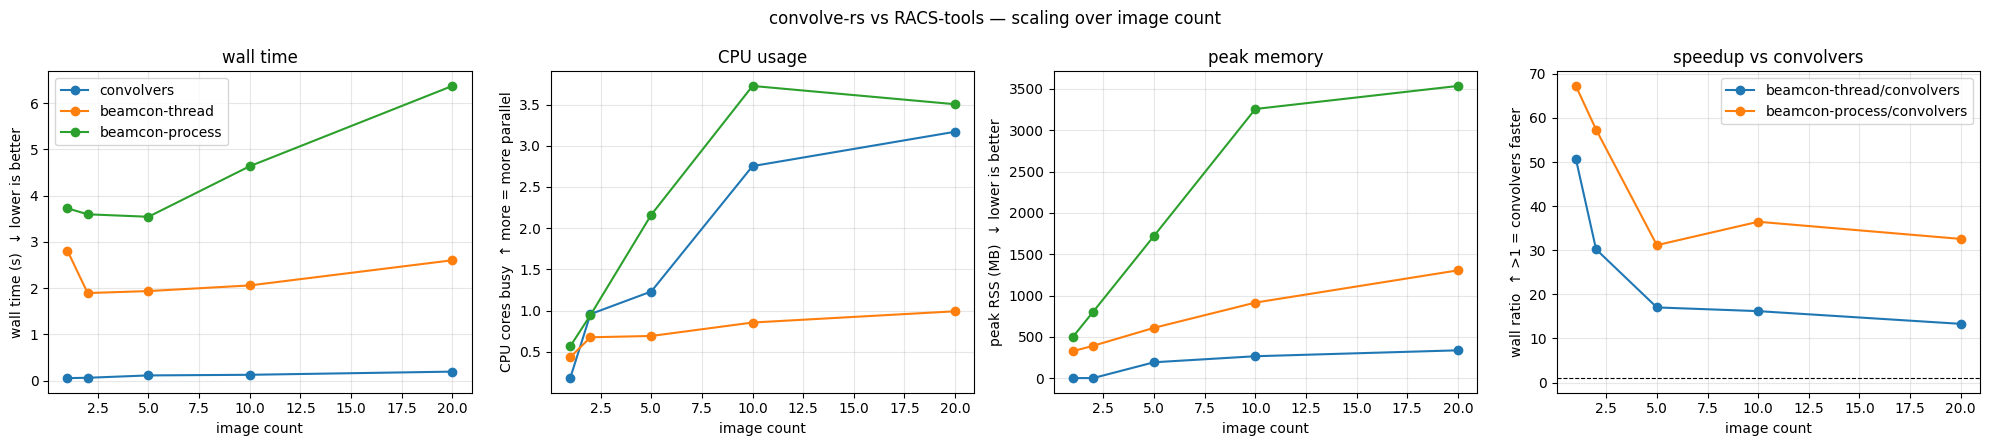

wrote bench_out/scaling_size.png


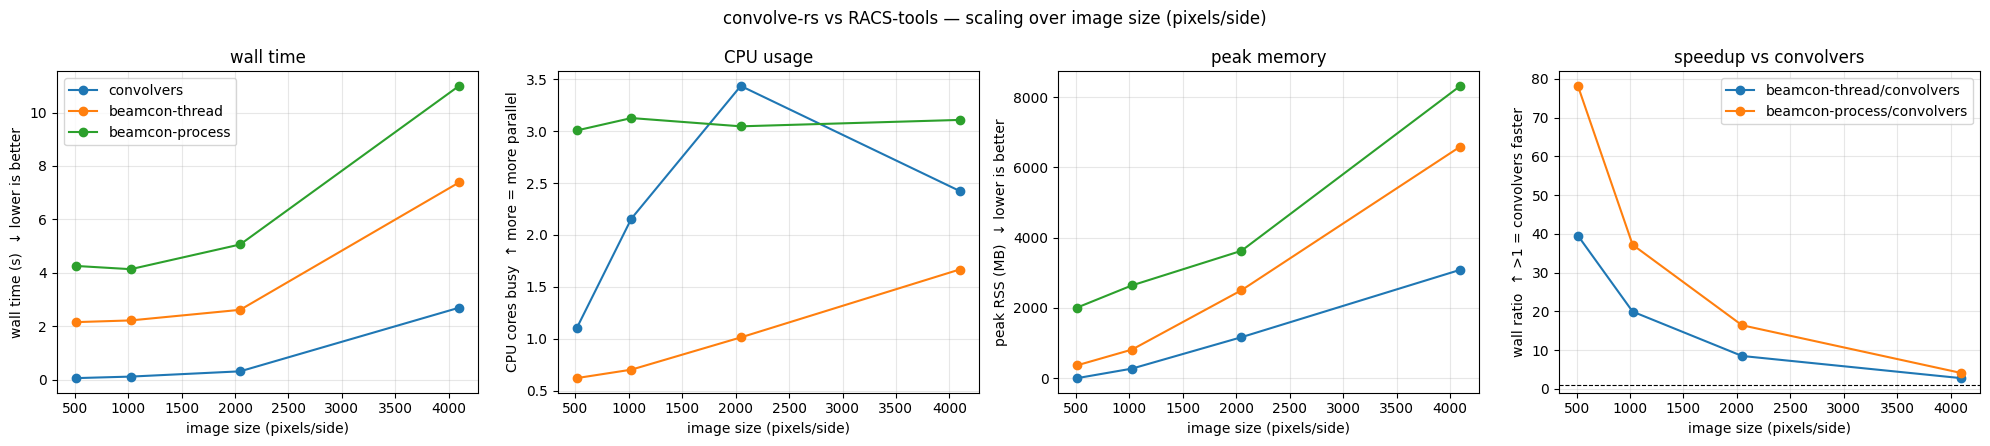

In [ ]:
def plot_sweep(df: pd.DataFrame, axis_label: str, fname: str):
    metrics = [
        ("wall", "wall time (s)  ↓ lower is better", "wall time"),
        ("cores", "CPU cores busy  ↑ more = more parallel", "CPU usage"),
        ("rss_mb", "peak RSS (MB)  ↓ lower is better", "peak memory"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
    for ax, (col, ylabel, title) in zip(axes, metrics, strict=False):
        for label in RUNNERS:
            sub = df[df.runner == label].sort_values("axis_value")
            ax.plot(sub.axis_value, sub[col], "o-", label=label)
        ax.set(xlabel=axis_label, ylabel=ylabel, title=title)
        ax.grid(alpha=0.3)
    axes[0].legend()

    ax = axes[3]
    rs = df[df.runner == "convolvers"].set_index("axis_value").wall
    for label, executor in RUNNERS.items():
        if executor is None:
            continue
        sub = df[df.runner == label].set_index("axis_value").wall
        ratio = (sub / rs).sort_index()
        ax.plot(ratio.index, ratio.values, "o-", label=f"{label}/convolvers")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.set(
        xlabel=axis_label,
        ylabel="wall ratio  ↑ >1 = convolvers faster",
        title="speedup vs convolvers",
    )
    ax.grid(alpha=0.3)
    ax.legend()

    fig.suptitle(f"convolve-rs vs RACS-tools — scaling over {axis_label}")
    fig.tight_layout()
    out = WORK / fname
    fig.savefig(out, dpi=120, bbox_inches="tight")
    print("wrote", out)
    plt.show()


plot_sweep(sweep_n, "image count", "scaling_count.png")
plot_sweep(sweep_sz, "image size (pixels/side)", "scaling_size.png")

## Thread scaling of convolvers

A batch of large (4096²) images while varying `RAYON_NUM_THREADS`. Each
f64-complex FFT has a working set of hundreds of MB, so a large-image batch is
limited by **memory bandwidth**, not CPU: speedup plateaus a few threads in. Good
to know before throwing all cores at it.

In [21]:
thr_root = WORK / "threads"
thr_infiles = gen_data(thr_root / "data", n=8, size=4096)
thr = []
for nt in [1, 2, 4, 8]:
    m = run_timed(
        build_cmd("convolvers", thr_infiles, thr_root / f"nt{nt}"),
        env_extra={"RAYON_NUM_THREADS": str(nt)},
    )
    thr.append(
        {"threads": nt, "wall": round(m["wall"], 2), "cores": round(m["cores"], 1)}
    )
pd.DataFrame(thr).set_index("threads")

,wall,cores
threads,,
1,3.27,1.0
2,1.94,1.7
4,1.35,2.7
8,1.08,4.7


## Correctness check

The comparison is only meaningful if both tools produce the same image. Assert the
outputs agree to float32 round-off on a large batch.

In [ ]:
chk = run_case("check", n=8, size=4096, reps=1)
diff = max_abs_diff(
    WORK / "check" / "convolvers_r0", WORK / "check" / "beamcon-process_r0"
)
rs = float(chk.loc[chk.runner == "convolvers", "wall"].iloc[0])
py = float(chk.loc[chk.runner == "beamcon-process", "wall"].iloc[0])
print(f"convolvers 8x4096      : {rs:.2f}s")
print(f"beamcon-process 8x4096 : {py:.2f}s")
print(f"max |Δ| (rs vs beamcon): {diff:.2e}")
assert diff < 1e-5, f"outputs disagree: {diff:.2e}"
print("OK — outputs agree to float32 round-off")

convolvers 8x4096      : 3.30s
beamcon-process 8x4096 : 13.86s
max |Δ| (rs vs beamcon): 2.38e-07
OK — outputs agree to float32 round-off


convolvers 8x4096      : 1.08s
beamcon-process 8x4096 : 11.88s
max |Δ| (rs vs beamcon): 2.38e-07
OK — outputs agree to float32 round-off


## Notes

- `cores busy` = (user + sys CPU seconds) / wall; >1 means real parallelism.
- convolvers parallelises across images. beamcon's `thread` executor is GIL-bound
  (~1 core); `process` uses a worker pool — faster on CPU but heavier on startup
  and memory.
- Large-image batches are memory-bandwidth bound and won't scale to all cores.
- Peak RSS is sampled across the **whole process tree**, so beamcon's `process`
  workers are counted. `/usr/bin/time`'s own `maximum resident set size` is
  parent-only and would under-count a worker pool several-fold — convolvers is
  single-process (threads) and fully captured either way.
- Outputs match to float32 round-off (max |Δ| ~1e-6), so the speed/memory
  comparison is apples-to-apples.